# Imports

In [12]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Load Dataset

In [13]:
df = pd.read_csv("../data/processed/cleaned_jobs.csv")

# Create Sentiment Labels

In [14]:
df['sentiment'] = df['company_rating'].apply(
    lambda x: 1 if x >= 3.5 else 0
)

# TF-IDF

In [15]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['sentiment']

In [17]:
import joblib

joblib.dump(
    vectorizer,
    "../outputs/models/tfidf_vectorizer.pkl"
)

['../outputs/models/tfidf_vectorizer.pkl']

# Train/Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

# Balanced Logistic Regression
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

log_model.fit(X_train, y_train)

preds = log_model.predict(X_test)

print("Accuracy:")
print(accuracy_score(y_test, preds))

print(classification_report(
    y_test,
    preds,
    zero_division=0
))

print("F1 Score:")
print(f1_score(y_test, preds))

# Probability scores
probs = log_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(
    y_test,
    probs
)

# ROC-AUC score
roc_auc = roc_auc_score(
    y_test,
    probs
)

print("ROC-AUC:", roc_auc)

print("\nConfusion Matrix:")
cm = confusion_matrix(
    y_test,
    preds
)

print(cm)

Accuracy:
0.711864406779661
              precision    recall  f1-score   support

           0       0.59      0.63      0.61        63
           1       0.79      0.75      0.77       114

    accuracy                           0.71       177
   macro avg       0.69      0.69      0.69       177
weighted avg       0.72      0.71      0.71       177

F1 Score:
0.7713004484304933
ROC-AUC: 0.7976886661097188

Confusion Matrix:
[[40 23]
 [28 86]]


In [20]:
import joblib

joblib.dump(
    log_model,
    "../outputs/models/logistic_regression.pkl"
)

['../outputs/models/logistic_regression.pkl']

# Plot ROC Curve

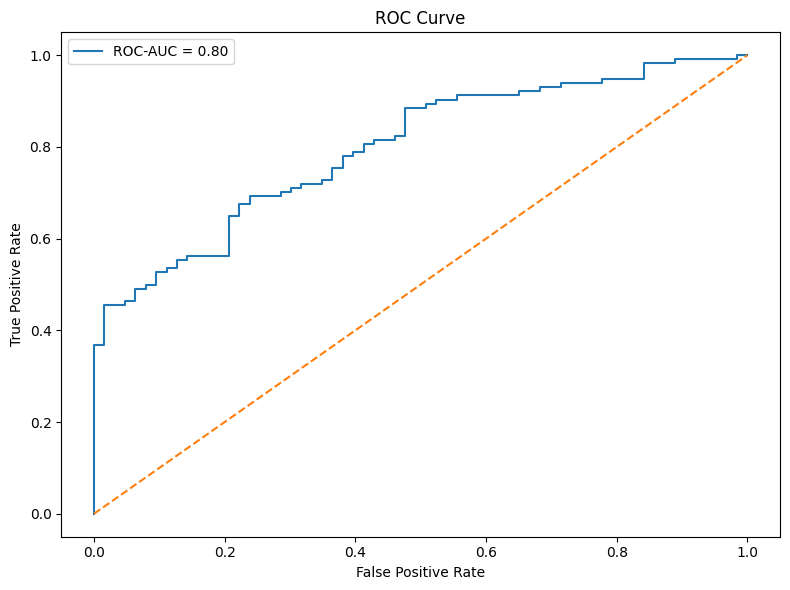

In [21]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/roc_curve.png"
)

plt.show()

# Plot Confusion Matrix

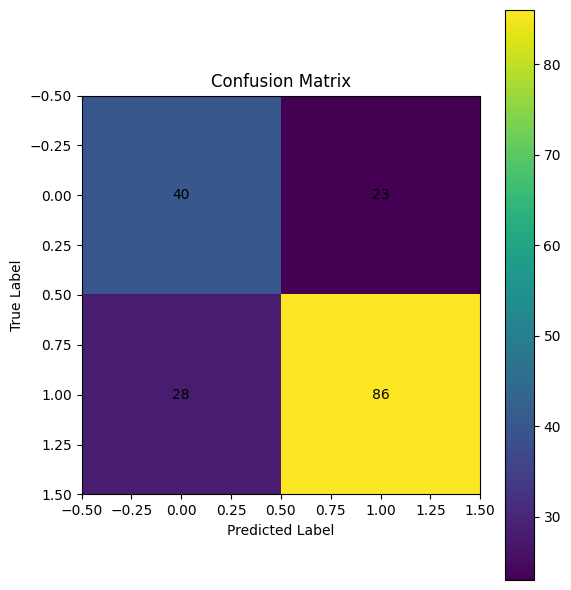

In [22]:
plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

# Add numbers
for i in range(len(cm)):
    for j in range(len(cm[0])):

        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/figures/confusion_matrix.png"
)

plt.show()

# Naive Bayes

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [24]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Model
nb_model = MultinomialNB()

# Train on RESAMPLED data
nb_model.fit(
    X_train_resampled,
    y_train_resampled
)

# Predict
nb_preds = nb_model.predict(X_test)

# Accuracy
print("Accuracy:")
print(accuracy_score(y_test, nb_preds))

# F1
print("\\nF1 Score:")
print(f1_score(y_test, nb_preds))

# Report
print("\\nClassification Report:")
print(classification_report(
    y_test,
    nb_preds,
    zero_division=0
))

# Confusion Matrix
print("\\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    nb_preds
))

Accuracy:
0.6892655367231638
\nF1 Score:
0.729064039408867
\nClassification Report:
              precision    recall  f1-score   support

           0       0.55      0.76      0.64        63
           1       0.83      0.65      0.73       114

    accuracy                           0.69       177
   macro avg       0.69      0.71      0.68       177
weighted avg       0.73      0.69      0.70       177

\nConfusion Matrix:
[[48 15]
 [40 74]]


In [25]:
joblib.dump(
    nb_model,
    "../outputs/models/naive_bayes.pkl"
)

['../outputs/models/naive_bayes.pkl']